In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the final product
df = pd.read_csv('../data/processed/modeling_ready_data.csv')

print("--- FINAL DATA CHECK ---")
print(f"Total Entries: {len(df)}")
print(f"Column Count: {len(df.columns)}")
#curr is 194

--- FINAL DATA CHECK ---
Total Entries: 1906
Column Count: 88


In [3]:
percent_null = df['Cap Pct'].isnull().mean() * 100
print(percent_null)

0.0


In [4]:
print(df.shape)

(1906, 88)


In [5]:
missing_counts = df.isna().sum().sort_values(ascending=False)

print("--- DATAFRAME INFO ---")
print(df.dtypes.value_counts())
print()
print("Columns with missing values:")
print(missing_counts[missing_counts > 0].head(20))

--- DATAFRAME INFO ---
float64    76
object      6
int64       6
Name: count, dtype: int64

Columns with missing values:
Series([], dtype: int64)


In [6]:
key_summary_cols = [
    'Age',
    'Games Played',
    'Cap Pct',
    'TOI Per 60',
    'Faceoff Pct',
]

print("--- KEY SUMMARY STATS ---")
print(df[key_summary_cols].describe().T)

--- KEY SUMMARY STATS ---
               count       mean        std        min       25%        50%  \
Age           1906.0  26.334208   4.060960  18.000000  23.00000  26.000000   
Games Played  1906.0  64.994753  16.156615  20.000000  55.00000  69.000000   
Cap Pct       1906.0   4.966530   3.364013   0.786164   1.69697   4.825057   
TOI Per 60    1906.0  17.678716   3.733490   6.400000  15.00000  17.783333   
Faceoff Pct   1906.0  22.665792  23.810782   0.000000   0.00000   0.000000   

                    75%        max  
Age           29.000000  39.000000  
Games Played  79.000000  82.000000  
Cap Pct        7.305389  15.723270  
TOI Per 60    20.150000  26.833333  
Faceoff Pct   46.900000  66.700000  


In [7]:
duplicate_rows = df.duplicated(['Player', 'Season', 'Team']).sum()
season_team_counts = df.groupby('Season')['Team'].nunique().sort_index()

print("--- KEY INTEGRITY CHECKS ---")
print(f"Duplicate player-season-team rows: {duplicate_rows}")
print()
print("Distinct teams represented by season:")
print(season_team_counts)
print()
print("Position counts:")
print(df['Position'].value_counts())

--- KEY INTEGRITY CHECKS ---
Duplicate player-season-team rows: 0

Distinct teams represented by season:
Season
2018    31
2019    31
2020    31
2021    31
2022    32
2023    32
2024    31
Name: Team, dtype: int64

Position counts:
Position
D     679
C     660
LW    291
RW    239
F      31
W       6
Name: count, dtype: int64


In [8]:
toi_parts = df['Total Ice Time'].astype(str).str.split(':', expand=True)
df['Total TOI Minutes'] = (
    pd.to_numeric(toi_parts[0], errors='coerce')
    + pd.to_numeric(toi_parts[1], errors='coerce') / 60
)

team_season_summary = (
    df.groupby(['Season', 'Team'])
    .agg(
        players=('Player', 'count'),
        cap_pct_total=('Cap Pct', 'sum'),
        total_toi_minutes=('Total TOI Minutes', 'sum'),
    )
    .reset_index()
)

print("--- TEAM-SEASON COVERAGE CHECKS ---")
print("These totals reflect the filtered modeling sample, not full team payroll or full roster ice time.")
print()
print(team_season_summary[['players', 'cap_pct_total', 'total_toi_minutes']].describe())
print()
print("Lowest cap-share coverage team-seasons:")
print(team_season_summary.nsmallest(10, 'cap_pct_total')[['Season', 'Team', 'players', 'cap_pct_total']])
print()
print("Lowest TOI coverage team-seasons:")
print(team_season_summary.nsmallest(10, 'total_toi_minutes')[['Season', 'Team', 'players', 'total_toi_minutes']])

--- TEAM-SEASON COVERAGE CHECKS ---
These totals reflect the filtered modeling sample, not full team payroll or full roster ice time.

          players  cap_pct_total  total_toi_minutes
count  219.000000     219.000000         219.000000
mean     8.703196      43.224684       10159.127321
std      2.458563      13.655010        3121.157693
min      3.000000       7.622698        3670.000000
25%      7.000000      33.384049        7875.850000
50%      9.000000      43.722556       10225.033333
75%     10.000000      52.060481       12289.575000
max     17.000000      85.386848       19156.533333

Lowest cap-share coverage team-seasons:
     Season Team  players  cap_pct_total
51     2019  OTT        5       7.622698
211    2024  SJS        3       7.799242
20     2018  OTT        4      11.306079
72     2020  DET        5      12.890593
74     2020  FLA        3      16.523518
67     2020  CBJ        7      19.259661
125    2022  ARI        7      20.277828
76     2020  MIN        4   

In [9]:
corr_matrix = df.corr(numeric_only=True)

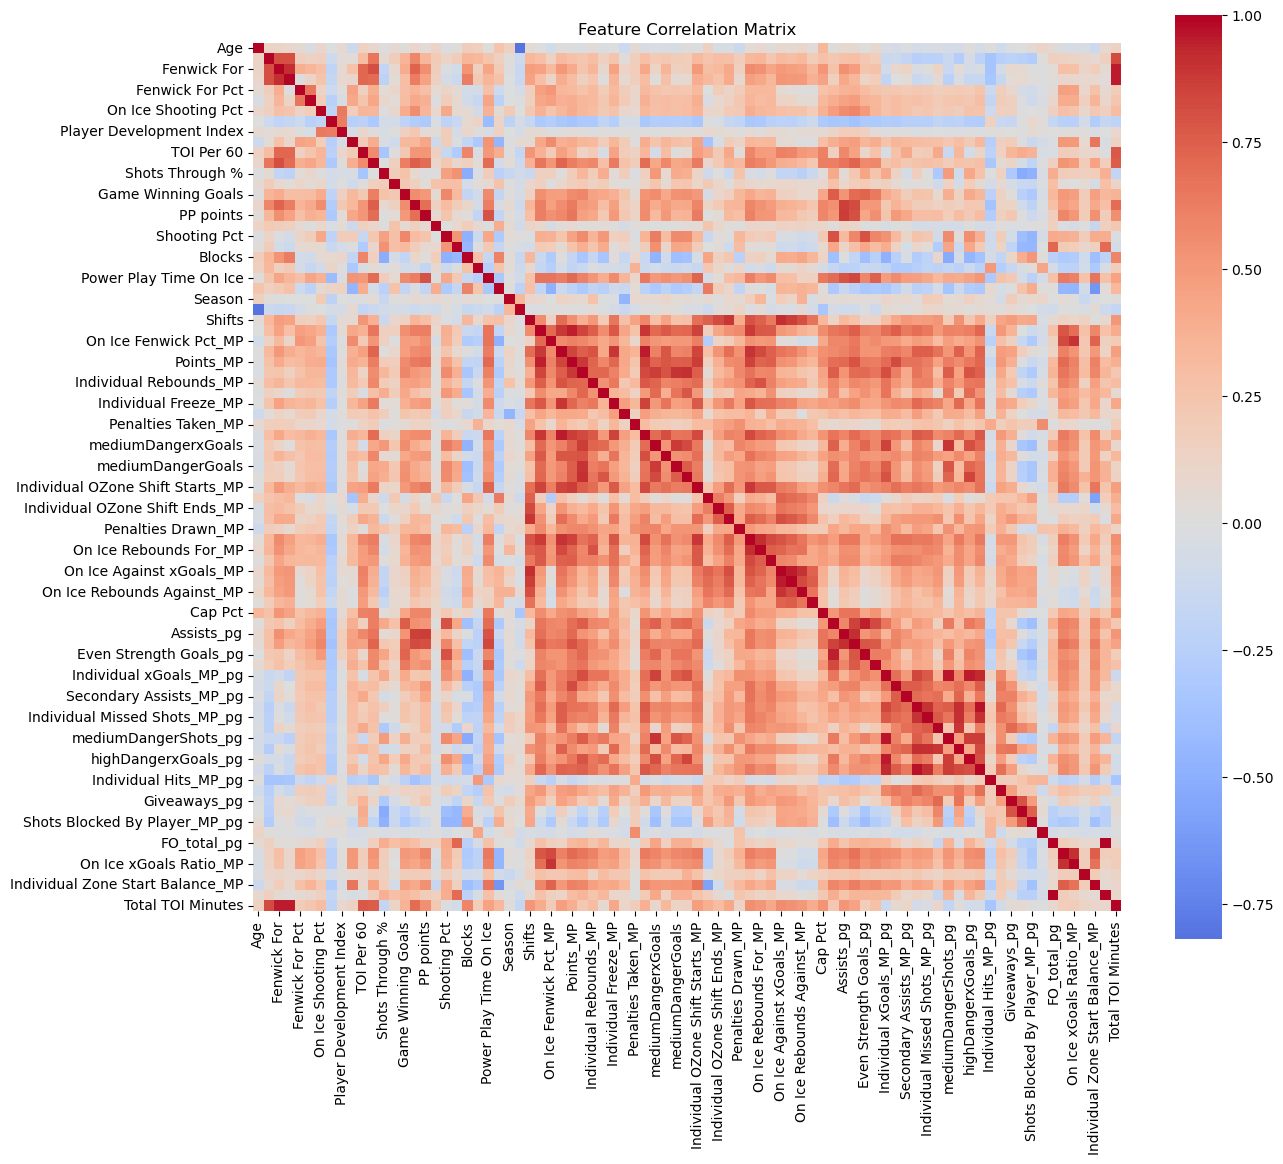

In [10]:
plt.figure(figsize=(14,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
threshold = 0.9

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, corr))

for pair in high_corr_pairs:
    print(pair)

('Fenwick Against', 'Fenwick For', np.float64(0.912452542596023))
('Points_MP', 'Game Score', np.float64(0.9476163095099926))
('lowDangerxGoals', 'Individual Shot Attempts_MP', np.float64(0.9553984052620076))
('highDangerGoals', 'Goals_MP', np.float64(0.9039694639090464))
('On Ice Rebounds For_MP', 'On Ice For xGoals_MP', np.float64(0.9155347841134562))
('On Ice Against xGoals_MP', 'Shifts', np.float64(0.9122294743694491))
('On Ice Goals Against_MP', 'On Ice Against xGoals_MP', np.float64(0.9506233740896161))
('Points_pg', 'Assists_pg', np.float64(0.9214636114023597))
('Even Strength Goals_pg', 'Goals_pg', np.float64(0.9482095295928258))
('mediumDangerShots_pg', 'Individual xGoals_MP_pg', np.float64(0.9576950845744256))
('lowDangerShots_pg', 'Individual Shots On Goal_MP_pg', np.float64(0.9179699997534021))
('lowDangerShots_pg', 'Individual Missed Shots_MP_pg', np.float64(0.9046336817966781))
('highDangerxGoals_pg', 'Individual xGoals_MP_pg', np.float64(0.9505006324667631))
('Individual

In [12]:
from collections import Counter

feature_counts = Counter([f for pair in high_corr_pairs for f in pair[:2]])

print(feature_counts)

Counter({'Individual xGoals_MP_pg': 3, 'Individual xRebounds_MP_pg': 3, 'Fenwick Against': 2, 'Fenwick For': 2, 'On Ice Against xGoals_MP': 2, 'lowDangerShots_pg': 2, 'Individual Shots On Goal_MP_pg': 2, 'Individual Missed Shots_MP_pg': 2, 'Total TOI Minutes': 2, 'Points_MP': 1, 'Game Score': 1, 'lowDangerxGoals': 1, 'Individual Shot Attempts_MP': 1, 'highDangerGoals': 1, 'Goals_MP': 1, 'On Ice Rebounds For_MP': 1, 'On Ice For xGoals_MP': 1, 'Shifts': 1, 'On Ice Goals Against_MP': 1, 'Points_pg': 1, 'Assists_pg': 1, 'Even Strength Goals_pg': 1, 'Goals_pg': 1, 'mediumDangerShots_pg': 1, 'highDangerxGoals_pg': 1, 'On Ice xGoals Ratio_MP': 1, 'On Ice xGoals Diff_MP': 1, 'Faceoff Impact_pg': 1, 'FO_total_pg': 1})


In [14]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(abs(upper[column]) > 0.9)]

df_reduced = df.drop(columns=to_drop)

In [15]:
drop_details = []

for column in to_drop:
    correlated_series = upper[column].dropna()
    if correlated_series.empty:
        drop_details.append((column, None, np.nan))
        continue

    partner = correlated_series.abs().idxmax()
    corr_value = correlated_series.loc[partner]
    drop_details.append((column, partner, corr_value))

print('--- DROPPED BY CORRELATION FILTER ---')
for column, partner, corr_value in drop_details:
    print(f"{column} | paired with: {partner} | corr: {corr_value:.4f}")


--- DROPPED BY CORRELATION FILTER ---
Fenwick Against | paired with: Fenwick For | corr: 0.9125
Points_MP | paired with: Game Score | corr: 0.9476
lowDangerxGoals | paired with: Individual Shot Attempts_MP | corr: 0.9554
highDangerGoals | paired with: Goals_MP | corr: 0.9040
On Ice Rebounds For_MP | paired with: On Ice For xGoals_MP | corr: 0.9155
On Ice Against xGoals_MP | paired with: Shifts | corr: 0.9122
On Ice Goals Against_MP | paired with: On Ice Against xGoals_MP | corr: 0.9506
Points_pg | paired with: Assists_pg | corr: 0.9215
Even Strength Goals_pg | paired with: Goals_pg | corr: 0.9482
mediumDangerShots_pg | paired with: Individual xGoals_MP_pg | corr: 0.9577
lowDangerShots_pg | paired with: Individual Shots On Goal_MP_pg | corr: 0.9180
highDangerxGoals_pg | paired with: Individual xGoals_MP_pg | corr: 0.9505
Individual xRebounds_MP_pg | paired with: Individual Shots On Goal_MP_pg | corr: 0.9684
On Ice xGoals Ratio_MP | paired with: On Ice xGoals Diff_MP | corr: 0.9029
Faceo

In [16]:
print(df_reduced.shape)

(1906, 73)


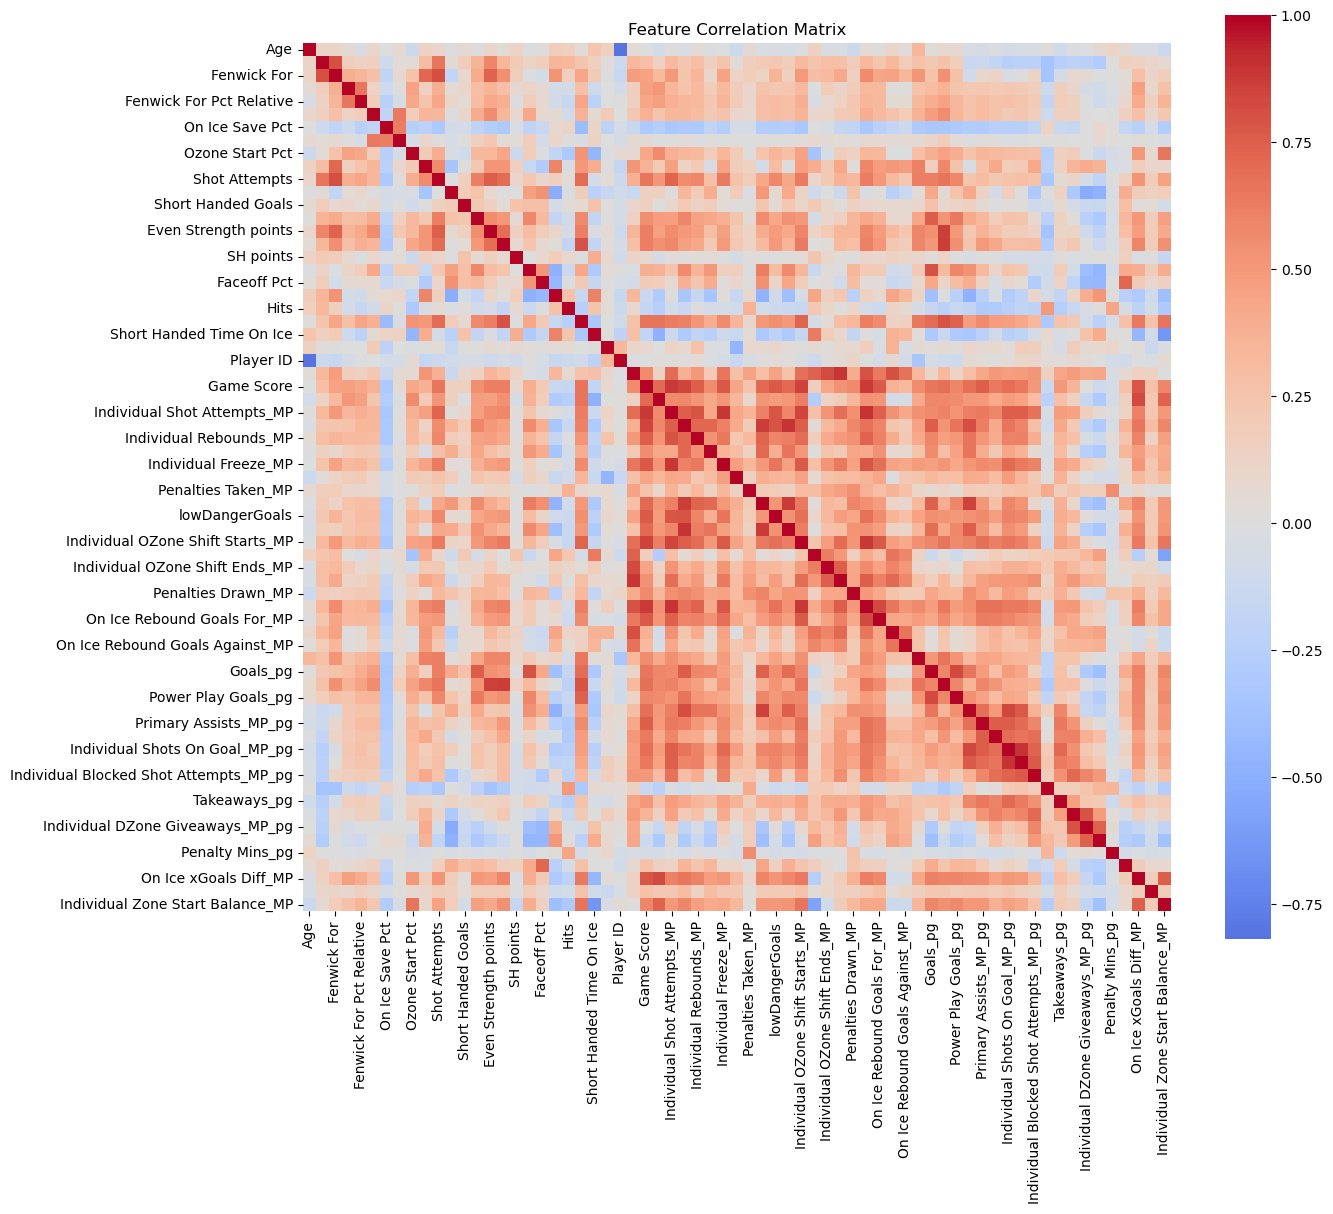

In [17]:
red_corr_matrix = df_reduced.corr(numeric_only=True)
plt.figure(figsize=(14,12))

sns.heatmap(
    red_corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()